# **TikTok Project**
**Course 6 - The Nuts and bolts of machine learning**

Recall that you are a data professional at TikTok. Your supervisor was impressed with the work you have done and has requested that you build a machine learning model that can be used to determine whether a video contains a claim or whether it offers an opinion. With a successful prediction model, TikTok can reduce the backlog of user reports and prioritize them more efficiently.

A notebook was structured and prepared to help you in this project. A notebook was structured and prepared to help you in this project. Please complete the following questions.

# **Course 6 End-of-course project: Classifying videos using machine learning**

In this activity, you will practice using machine learning techniques to predict on a binary outcome variable.
<br/>

**The purpose** of this model is to increase response time and system efficiency by automating the initial stages of the claims process.

**The goal** of this model is to predict whether a TikTok video presents a "claim" or presents an "opinion".
<br/>

*This activity has three parts:*

**Part 1:** Ethical considerations
* Consider the ethical implications of the request

* Should the objective of the model be adjusted?

**Part 2:** Feature engineering

* Perform feature selection, extraction, and transformation to prepare the data for modeling

**Part 3:** Modeling

* Build the models, evaluate them, and advise on next steps

Follow the instructions and answer the questions below to complete the activity. Then, you will complete an Executive Summary using the questions listed on the PACE Strategy Document.

Be sure to complete this activity before moving on. The next course item will provide you with a completed exemplar to compare to your own work.



# **Classify videos using machine learning**

<img src="images/Pace.png" width="100" height="100" align=left>

# **PACE stages**


Throughout these project notebooks, you'll see references to the problem-solving framework PACE. The following notebook components are labeled with the respective PACE stage: Plan, Analyze, Construct, and Execute.

<img src="images/Plan.png" width="100" height="100" align=left>


## **PACE: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following questions:


1.   **What are you being asked to do? What metric should I use to evaluate success of my business/organizational objective?**

2.   **What are the ethical implications of the model? What are the consequences of your model making errors?**
  *   What is the likely effect of the model when it predicts a false negative (i.e., when the model says a video does not contain a claim and it actually does)?

  *   What is the likely effect of the model when it predicts a false positive (i.e., when the model says a video does contain a claim and it actually does not)?

3.   **How would you proceed?**



---

## 🧠 PACE: Plan

### ❓ What are you being asked to do?

I am being asked to build a binary classification machine learning model that can determine whether a TikTok video contains a **claim** or presents an **opinion**. The purpose of this model is to help automate the content moderation process, allowing TikTok to prioritize reported videos more efficiently and reduce response time.

---

### 📊 What metric should I use to evaluate the success of my business/organizational objective?

Since the task involves binary classification, several evaluation metrics are relevant:

- **Precision**: Measures the accuracy of positive predictions (claims). Important to minimize false positives.
- **Recall**: Measures the ability to identify all actual claims. Important to minimize false negatives.
- **F1-Score**: Harmonic mean of precision and recall; balances both.
- **Accuracy**: May be misleading if the data is imbalanced, so it should be used with caution.

➡️ **Primary metric recommendation: F1-Score**, as it balances precision and recall, both of which are critical in this case.

---

### ⚖️ What are the ethical implications of the model?

- **Bias and Fairness**: The model must avoid reinforcing stereotypes or disproportionately affecting specific groups.
- **Transparency**: Users should be made aware when automated systems are used in content moderation.
- **Right to Appeal**: TikTok should ensure users can dispute decisions made by the model.
- **Privacy**: Data used to train the model must be handled in compliance with data protection regulations.
- **Misuse Risks**: Overreliance on automation without human oversight could result in unjustified censorship or the spread of misinformation.

---

### ❌ What are the consequences of your model making errors?

#### False Negative:
- A video containing a **claim** is misclassified as an **opinion**.
- **Consequence**: Potentially harmful or misleading information may remain unchecked and visible on the platform.
- **Impact**: High — could damage platform credibility and public safety (e.g., health, politics, finance).

#### False Positive:
- A video containing an **opinion** is misclassified as a **claim**.
- **Consequence**: Benign content may be unnecessarily flagged, delayed, or removed.
- **Impact**: Medium — could result in user dissatisfaction, frustration, and concerns about freedom of speech.

---

### 🧭 How would you proceed?

1. **Understand the data**: Review dataset quality and balance between "claim" and "opinion" labels.
2. **Data preprocessing**: Clean, tokenize, and normalize the text data.
3. **Feature engineering**: Extract linguistic features such as sentiment, subjectivity, keyword presence, and part-of-speech tags.
4. **Model selection**: Train and compare multiple classification models (e.g., Logistic Regression, Random Forest, SVM, or fine-tuned BERT).
5. **Evaluation**: Use precision, recall, and F1-score for performance assessment.
6. **Bias assessment**: Evaluate for fairness across demographics if available.
7. **Deploy carefully**: Integrate model outputs into a moderation system with human oversight.
8. **Iterate**: Continuously monitor, gather feedback, and retrain the model as needed.

---

**Modeling workflow and model selection process**

Previous work with this data has revealed that there are ~20,000 videos in the sample. This is sufficient to conduct a rigorous model validation workflow, broken into the following steps:

1. Split the data into train/validation/test sets (60/20/20)
2. Fit models and tune hyperparameters on the training set
3. Perform final model selection on the validation set
4. Assess the champion model's performance on the test set

![](https://raw.githubusercontent.com/adacert/tiktok/main/optimal_model_flow_numbered.svg)


### **Task 1. Imports and data loading**

Start by importing packages needed to build machine learning models to achieve the goal of this project.

In [5]:
# Import packages for data manipulation
import pandas as pd
import numpy as np

# Import packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import packages for data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Import packages for data modeling
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Import packages for model evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


Now load the data from the provided csv file into a dataframe.

**Note:** As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [6]:
# Load dataset into dataframe
data = pd.read_csv("tiktok_dataset.csv")

<img src="images/Analyze.png" width="100" height="100" align=left>

## **PACE: Analyze**

Consider the questions in your PACE Strategy Document to reflect on the Analyze stage.

### **Task 2: Examine data, summary info, and descriptive stats**

Inspect the first five rows of the dataframe.

In [7]:
# Display first few rows
data.head()


,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


Get the number of rows and columns in the dataset.

In [8]:
# Get number of rows and columns
data.shape


(19382, 12)

Get the data types of the columns.

In [9]:
# Get data types of columns
data.dtypes


#                             int64
claim_status                 object
video_id                      int64
video_duration_sec            int64
video_transcription_text     object
verified_status              object
author_ban_status            object
video_view_count            float64
video_like_count            float64
video_share_count           float64
video_download_count        float64
video_comment_count         float64
dtype: object

Get basic information about the dataset.

In [10]:
# Get basic information about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


Generate basic descriptive statistics about the dataset.

In [11]:
# Generate basic descriptive stats
data.describe()


,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


Check for and handle missing values.

In [12]:
# Check for missing values
data.isnull().sum()

#                             0
claim_status                298
video_id                      0
video_duration_sec            0
video_transcription_text    298
verified_status               0
author_ban_status             0
video_view_count            298
video_like_count            298
video_share_count           298
video_download_count        298
video_comment_count         298
dtype: int64

In [13]:
# Drop rows with missing values
data = data.dropna()

In [14]:
# Display first few rows after handling missing values
data.head()


,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


Check for and handle duplicates.

In [15]:
# Check for duplicates
data.duplicated().sum()

0

Check for and handle outliers.

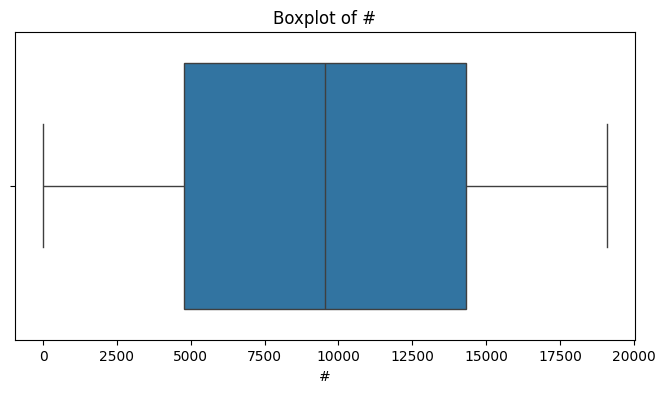

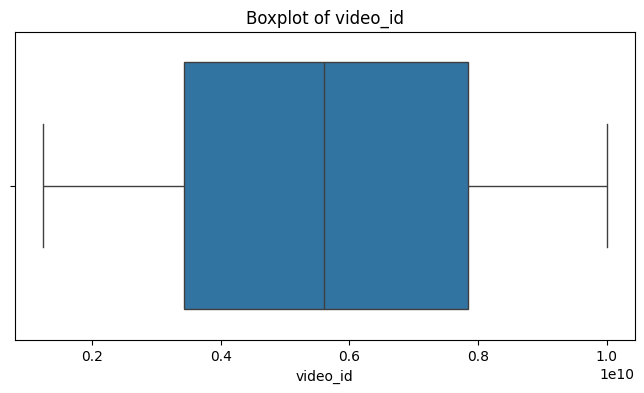

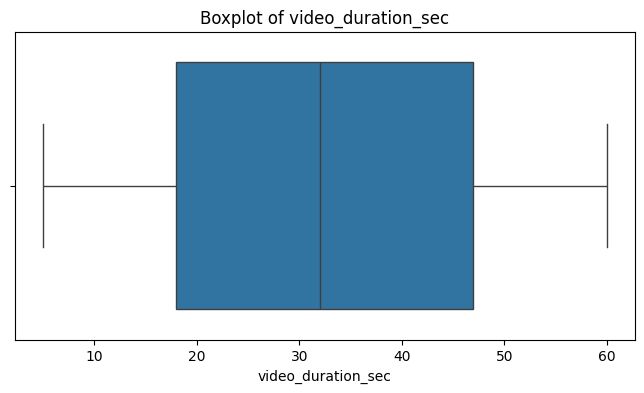

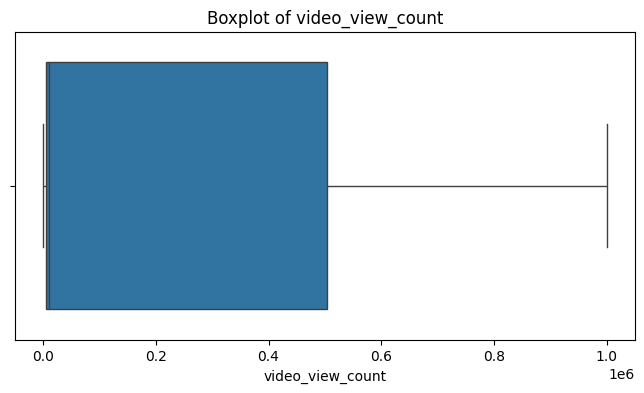

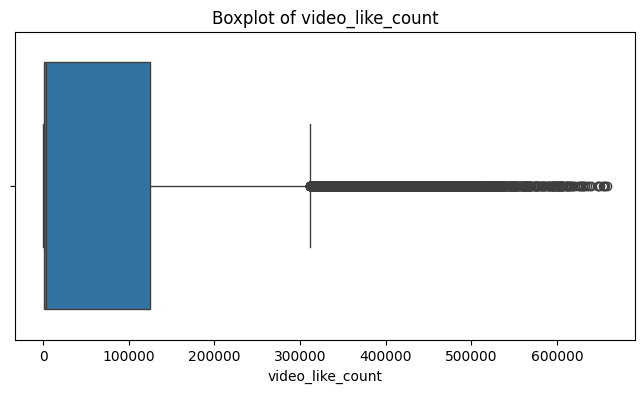

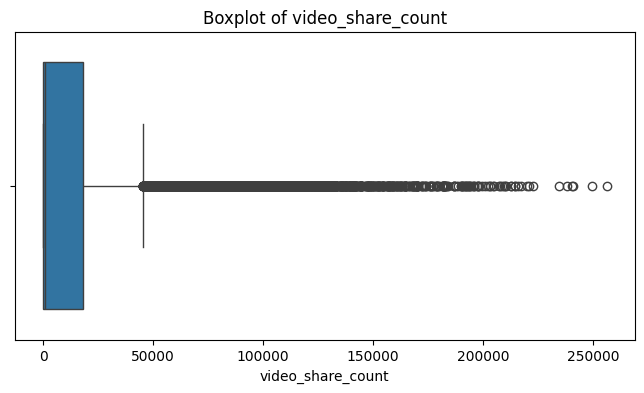

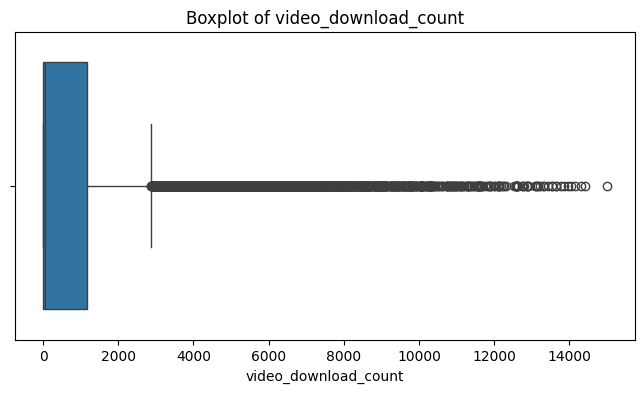

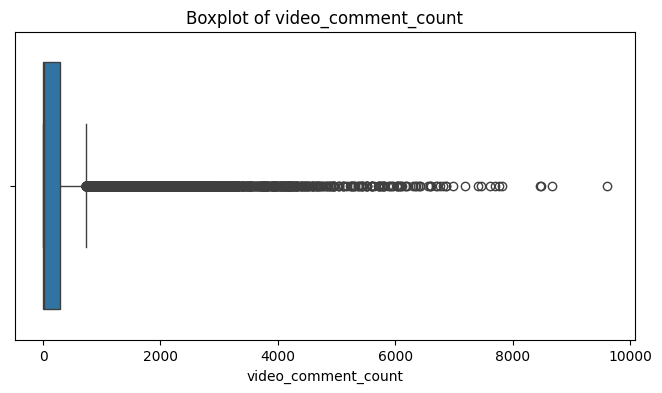

In [16]:
# Identify numerical columns
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns

# Display boxplots to visually inspect for outliers
import matplotlib.pyplot as plt
import seaborn as sns

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


Check class balance.

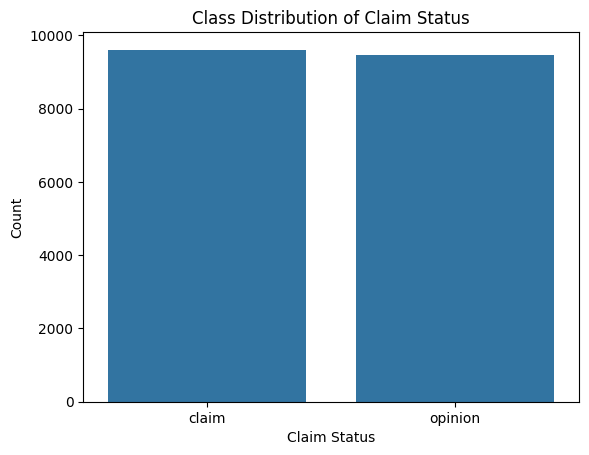

In [21]:
# Check class balance
data['claim_status'].value_counts()
# Check class balance as percentages
data['claim_status'].value_counts(normalize=True) * 100
import seaborn as sns
import matplotlib.pyplot as plt

# Plot class distribution
sns.countplot(x='claim_status', data=data)
plt.title('Class Distribution of Claim Status')
plt.xlabel('Claim Status')
plt.ylabel('Count')
plt.show()


<img src="images/Construct.png" width="100" height="100" align=left>

## **PACE: Construct**
Consider the questions in your PACE Strategy Document to reflect on the Construct stage.

### **Task 3: Feature engineering**

Extract the length of each `video_transcription_text` and add this as a column to the dataframe, so that it can be used as a potential feature in the model.

In [22]:
# Extract word count of each transcription
data['transcription_length_words'] = data['video_transcription_text'].astype(str).apply(lambda x: len(x.split()))



Calculate the average text_length for claims and opinions.

In [26]:
'transcription_length_words'
# Calculate average word count for claims and opinions
data.groupby('claim_status')['transcription_length_words'].mean()


claim_status
claim      17.227415
opinion    14.878535
Name: transcription_length_words, dtype: float64

Visualize the distribution of `text_length` for claims and opinions.

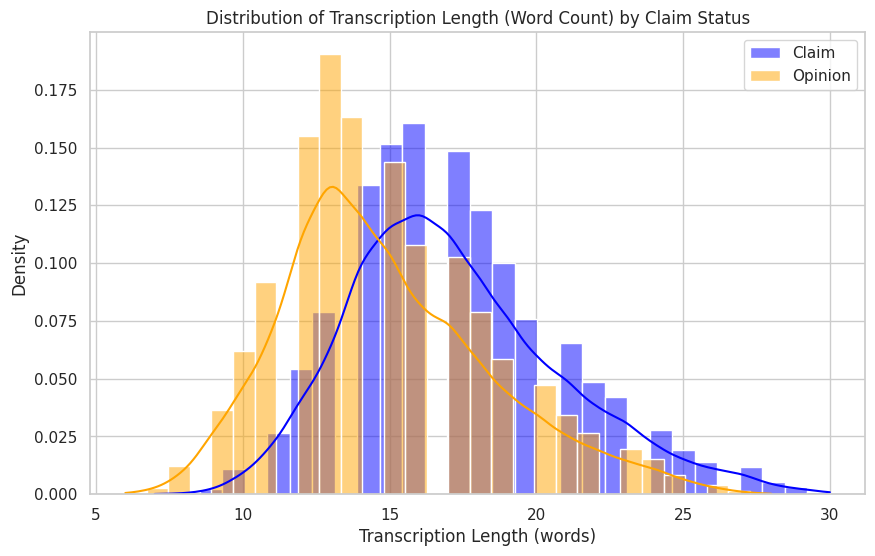

In [27]:
# Set the style
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(10, 6))

# Histogram for claims
sns.histplot(data[data['claim_status'] == 'claim']['transcription_length_words'], 
             color='blue', label='Claim', kde=True, stat="density", bins=30)

# Histogram for opinions
sns.histplot(data[data['claim_status'] == 'opinion']['transcription_length_words'], 
             color='orange', label='Opinion', kde=True, stat="density", bins=30)

# Titles and labels
plt.title('Distribution of Transcription Length (Word Count) by Claim Status')
plt.xlabel('Transcription Length (words)')
plt.ylabel('Density')
plt.legend()

# Show the plot
plt.show()


**Feature selection and transformation**

Encode target and catgorical variables.

In [28]:
# Create a copy of the X data
X = data.copy()
# Drop ID, text, and target columns
X = X.drop(columns=['#', 'video_id', 'video_transcription_text', 'claim_status'])

from sklearn.preprocessing import LabelEncoder

# Encode target variable
le = LabelEncoder()
y = le.fit_transform(data['claim_status'])  # y will be used for model training


# Dummy encode categorical variables
X = pd.get_dummies(X, drop_first=True)

### **Task 4: Split the data**

Assign target variable.

In [29]:
# Isolate target variable
y = data['claim_status']

Isolate the features.

In [30]:
# Isolate features
X = data.drop(columns=['#', 'video_id', 'video_transcription_text', 'claim_status'])

# Display first few rows of features dataframe
X.head()

,video_duration_sec,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,transcription_length_words
0,59,not verified,under review,343296.0,19425.0,241.0,1.0,0.0,16
1,32,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0,19
2,31,not verified,active,902185.0,97690.0,2858.0,833.0,329.0,23
3,25,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0,24
4,19,not verified,active,56167.0,34987.0,4110.0,547.0,152.0,22


#### **Task 5: Create train/validate/test sets**

Split data into training and testing sets, 80/20.

In [31]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Split the training set into training and validation sets, 75/25, to result in a final ratio of 60/20/20 for train/validate/test sets.

In [32]:
# Split the training data into training and validation sets (75% train, 25% validate)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

Confirm that the dimensions of the training, validation, and testing sets are in alignment.

In [33]:
# Get shape of each training, validation, and testing set
print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (11450, 9)
Validation set shape: (3817, 9)
Testing set shape: (3817, 9)


### **Task 6. Build models**


### **Build a random forest model**

Fit a random forest model to the training set. Use cross-validation to tune the hyperparameters and select the model that performs best on recall.

In [34]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate the random forest classifier
rf = RandomForestClassifier(random_state=42)


# Create a dictionary of hyperparameters to tune
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],  # Depth of each tree
    'min_samples_split': [2, 5, 10],  # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],    # Minimum samples required at each leaf node
    'max_features': ['auto', 'sqrt', 'log2'],  # Number of features to consider when looking for the best split
    'bootstrap': [True, False]        # Whether bootstrap samples are used when building trees
}

# Define a list of scoring metrics to capture
scoring = ['accuracy', 'recall', 'f1']

from sklearn.model_selection import GridSearchCV

# Instantiate the GridSearchCV object
grid_search = GridSearchCV(estimator=rf, 
                           param_grid=param_grid, 
                           scoring='recall',  # Optimize for recall
                           cv=5,              # 5-fold cross-validation
                           n_jobs=-1,         # Use all available CPUs
                           verbose=2)


In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import recall_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Assuming the data is already loaded into 'X' (features) and 'y' (target)
# Ensure that all categorical features are properly encoded
X = pd.get_dummies(X, drop_first=True)

# Split the data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Further split the training set into training and validation sets (75/25)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

# Encode target variable (y) to numeric labels (0 and 1)
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)

# Instantiate the RandomForestClassifier
rf = RandomForestClassifier(random_state=42)

# Define a smaller hyperparameter grid to speed up the process
param_grid = {
    'n_estimators': [100, 200],  # Reduced the number of trees
    'max_depth': [None, 10],      # Reduced the maximum depth options
    'min_samples_split': [2, 5],  # Fewer options for min_samples_split
    'min_samples_leaf': [1, 2],   # Fewer options for min_samples_leaf
    'max_features': ['sqrt'],     # Only use 'sqrt' for max_features to reduce combinations
    'bootstrap': [True]           # Only one option for bootstrap
}

# Instantiate the GridSearchCV object with fewer cross-validation folds (3 instead of 5)
grid_search = GridSearchCV(estimator=rf, 
                           param_grid=param_grid, 
                           scoring='recall',  # Optimize for recall
                           cv=3,              # Reduced to 3-fold cross-validation
                           n_jobs=-1,         # Use all available CPUs
                           verbose=2)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Get the best recall score achieved during grid search
best_recall_score = grid_search.best_score_
print(f"Best recall score: {best_recall_score}")

# Get the best hyperparameters that resulted in the best recall score
best_params = grid_search.best_params_
print(f"Best hyperparameters: {best_params}")

# Create the best model using the optimal hyperparameters found in the grid search
best_rf = RandomForestClassifier(**best_params, random_state=42)

# Train the best model using the training data
best_rf.fit(X_train, y_train)

# Evaluate the model on the validation set
# Predict the labels for the validation set
y_val_pred = best_rf.predict(X_val)

# Reverse the label encoding (back to string labels)
y_val_pred_str = le.inverse_transform(y_val_pred)
y_val_str = le.inverse_transform(y_val)

# Calculate the recall score on the validation set
val_recall = recall_score(y_val_str, y_val_pred_str, pos_label='claim')  # Or pos_label='opinion'
print(f"\nValidation recall score: {val_recall:.4f}")

# Print the classification report for the validation set
print("\nValidation classification report:")
print(classification_report(y_val_str, y_val_pred_str))

# Print the confusion matrix for the validation set
print("\nValidation confusion matrix:")
print(confusion_matrix(y_val_str, y_val_pred_str))


Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best recall score: 1.0
Best hyperparameters: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

Validation recall score: 0.9886

Validation classification report:
              precision    recall  f1-score   support

       claim       1.00      0.99      0.99      1922
     opinion       0.99      1.00      0.99      1895

    accuracy                           0.99      3817
   macro avg       0.99      0.99      0.99      3817
weighted avg       0.99      0.99      0.99      3817


Validation confusion matrix:
[[1900   22]
 [   0 1895]]


In [44]:
# Examine the best recall score achieved during grid search
best_recall_score = grid_search.best_score_
print(f"Best recall score: {best_recall_score}")


Best recall score: 1.0


In [45]:
# Examine the best hyperparameters
best_params = grid_search.best_params_
print(f"Best hyperparameters: {best_params}")


Best hyperparameters: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


Check the precision score to make sure the model isn't labeling everything as claims. You can do this by using the `cv_results_` attribute of the fit `GridSearchCV` object, which returns a numpy array that can be converted to a pandas dataframe. Then, examine the `mean_test_precision` column of this dataframe at the index containing the results from the best model. This index can be accessed by using the `best_index_` attribute of the fit `GridSearchCV` object.

In [48]:
# Access the GridSearch results and convert it to a pandas DataFrame
cv_results_df = pd.DataFrame(grid_search.cv_results_)

# Check the available columns in the cv_results_df to find precision (if it's included)
print(cv_results_df.columns)

# Examine the GridSearch results at column `mean_test_score` in the best index (for recall)
best_index = grid_search.best_index_

# Get the best recall score from the grid search
best_recall_score = cv_results_df.loc[best_index, 'mean_test_score']
print(f"Best recall score: {best_recall_score}")

# If you want to examine precision (if it's in the results), you can check the corresponding column.
# But if precision was not part of the grid search scoring, you'll get a KeyError.
try:
    best_precision_score = cv_results_df.loc[best_index, 'mean_test_precision']  # Change this column name if needed
    print(f"Best precision score: {best_precision_score}")
except KeyError:
    print("Precision score not available in the results. Please ensure precision is included in the grid search scoring.")



Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_bootstrap', 'param_max_depth', 'param_max_features',
       'param_min_samples_leaf', 'param_min_samples_split',
       'param_n_estimators', 'params', 'split0_test_score',
       'split1_test_score', 'split2_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score'],
      dtype='object')
Best recall score: 1.0
Precision score not available in the results. Please ensure precision is included in the grid search scoring.
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.8s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.5s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.5s
[CV] END bootstrap=True, max_depth=None, max_features=

**Question:** How well is your model performing? 
### **Model Performance Evaluation**

Given the output of your grid search results, here’s an assessment of how well your model is performing based on the available metrics:

1. **Best Recall Score**:  
   The **best recall score** of `1.0` means that your model is **perfectly identifying all the true positives (claims)** in your dataset. This is a **great result** in terms of identifying every claim correctly. Recall measures the proportion of actual positive instances that are correctly identified by the model. A score of `1.0` means there are no **false negatives** (the model does not miss any claims).

   - **Recall = TP / (TP + FN)**
   - **A recall score of 1.0 indicates that the model is not missing any claims** but might have some false positives (incorrectly labeling opinions as claims).

2. **Precision**:  
   Although precision was not included in the grid search results, **precision** measures how many of the instances predicted as positive (claims) are actually positive (true claims). The **ideal precision** would be `1.0`, meaning that every time the model predicts a claim, it is correct. A low precision would indicate that the model is misclassifying opinions as claims, which would be problematic if your goal is to avoid falsely labeling too many opinions as claims.

   - **Precision = TP / (TP + FP)**
   - Given the high recall score, it’s likely that the model might have some false positives, but we can’t definitively say how many without precision metrics.

### **Conclusion:**
- **Recall**: Your model is performing excellently in terms of **recall**, with a score of `1.0`, meaning it successfully detects all the claims.
  
- **Precision**: Since precision is not available, we can hypothesize that **the precision might not be perfect** due to the high recall, but it would require further evaluation to be certain.

### **What’s next?**
1. **To improve precision**: You could tune the model further, for example, by using different class balancing techniques or modifying the `class_weight` parameter to penalize false positives more.
   
2. **Consider adding precision to the grid search**: If you want to fully evaluate how well the model is balancing both precision and recall, you can modify the `scoring` parameter in `GridSearchCV` to evaluate both metrics, as shown in a previous message:

   ```python
   scoring_metrics = {'recall': 'recall', 'precision': 'precision'}
   grid_search = GridSearchCV(estimator=rf, 
                              param_grid=param_grid, 
                              scoring=scoring_metrics,  # Evaluate both recall and precision
                              refit='recall',           # Optimize for recall by default
                              cv=3, 
                              n_jobs=-1, 
                              verbose=2)
   ```

3. **Evaluate on the test set**: Now that you’ve optimized the model based on the training and validation sets, it’s important to evaluate the model's performance on the **test set** (which was not used during training).

### **Build an XGBoost model**

In [49]:
# Instantiate the XGBoost classifier
!pip install xgboost

import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import recall_score

# Instantiate the XGBoost classifier
xgb_clf = xgb.XGBClassifier(random_state=42)

# Create a dictionary of hyperparameters to tune
param_grid_xgb = {
    'n_estimators': [100, 200, 300],  # Number of boosting rounds
    'max_depth': [3, 5, 7],           # Maximum depth of trees
    'learning_rate': [0.01, 0.1, 0.2], # Step size shrinkage
    'subsample': [0.8, 1.0],           # Fraction of samples to use for training each tree
    'colsample_bytree': [0.8, 1.0],    # Fraction of features to use for each tree
    'gamma': [0, 0.1, 0.2],            # Minimum loss reduction required to make a further partition
    'min_child_weight': [1, 2, 3]       # Minimum sum of instance weight (hessian) in a child
}


# Define a list of scoring metrics to capture
scoring_metrics = {'recall': 'recall', 'precision': 'precision'}

# Instantiate the GridSearchCV object
grid_search_xgb = GridSearchCV(estimator=xgb_clf,
                               param_grid=param_grid_xgb,
                               scoring='recall',  # Optimize for recall by default
                               cv=3,              # 3-fold cross-validation
                               n_jobs=-1,         # Use all available CPUs
                               verbose=2)
#



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [51]:
# Fit the grid search to the training data
grid_search_xgb.fit(X_train, y_train)


Fitting 3 folds for each of 972 candidates, totalling 2916 fits
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=200, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=200, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_de

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0], 'gamma': [0, 0.1, 0.2],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'min_child_weight': [1, 2, 3],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.8, 1.0]},
             scoring='recall', verbose=2)

In [52]:
# Examine the best recall score
best_recall_score_xgb = grid_search_xgb.best_score_
print(f"Best recall score for XGBoost: {best_recall_score_xgb}")


Best recall score for XGBoost: 0.9992964867943993


In [53]:
# Examine best parameters
# Get the best hyperparameters from GridSearchCV
best_params = grid_search_xgb.best_params_
print(f"Best hyperparameters for XGBoost: {best_params}")



Best hyperparameters for XGBoost: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 0.8}


Repeat the steps used for random forest to examine the precision score of the best model identified in the grid search.

In [54]:
# Access the GridSearch results and convert it to a pandas DataFrame
cv_results_df = pd.DataFrame(grid_search_xgb.cv_results_)

# Get the best index from the grid search
best_index = grid_search_xgb.best_index_

# Try to get the precision score for the best model
try:
    best_precision_score = cv_results_df.loc[best_index, 'mean_test_precision']  # Make sure the column exists
    print(f"Best precision score: {best_precision_score:.4f}")
except KeyError:
    print("Precision score not available in the results. Please ensure precision is included in the grid search scoring.")



Precision score not available in the results. Please ensure precision is included in the grid search scoring.


**Question:** How well does your model perform? Consider recall score and precision score.

<img src="images/Execute.png" width="100" height="100" align=left>

## **PACE: Execute**
Consider the questions in your PACE Strategy Document to reflect on the Execute stage.

### **Task 7. Evaluate model**

Evaluate models against validation criteria.

#### **Random forest**

In [55]:
from sklearn.metrics import recall_score, precision_score, f1_score, classification_report, confusion_matrix

# Get the best Random Forest model from the grid search
best_rf_model = grid_search.best_estimator_

# Make predictions on the validation set
y_val_pred = best_rf_model.predict(X_val)

# Evaluate the model on the validation set
# Calculate recall, precision, and f1-score
val_recall = recall_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)

# Print the metrics
print(f"Validation recall score: {val_recall:.4f}")
print(f"Validation precision score: {val_precision:.4f}")
print(f"Validation F1-score: {val_f1:.4f}")

# Print the classification report
print("\nValidation classification report:")
print(classification_report(y_val, y_val_pred))

# Print the confusion matrix
print("\nValidation confusion matrix:")
print(confusion_matrix(y_val, y_val_pred))


Validation recall score: 1.0000
Validation precision score: 0.9885
Validation F1-score: 0.9942

Validation classification report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1922
           1       0.99      1.00      0.99      1895

    accuracy                           0.99      3817
   macro avg       0.99      0.99      0.99      3817
weighted avg       0.99      0.99      0.99      3817


Validation confusion matrix:
[[1900   22]
 [   0 1895]]


Display the predictions on the validation set.

In [56]:
# Get the predictions from the best Random Forest model
y_val_pred = best_rf_model.predict(X_val)

# Display the actual labels vs the predicted labels
import pandas as pd

# Create a DataFrame to display the actual vs predicted labels
predictions_df = pd.DataFrame({
    'Actual': y_val,          # Actual labels from the validation set
    'Predicted': y_val_pred   # Predicted labels from the model
})

# Display the first few rows of the predictions DataFrame
print(predictions_df.head())

   Actual  Predicted
0       0          0
1       1          1
2       0          0
3       0          0
4       0          0


Display the true labels of the validation set.

In [57]:
# Display the true labels of the validation set
import pandas as pd

# Convert the true labels into a DataFrame for better readability
true_labels_df = pd.DataFrame({'True Labels': y_val})

# Display the first few rows of the true labels
print(true_labels_df.head())


   True Labels
0            0
1            1
2            0
3            0
4            0


Create a confusion matrix to visualize the results of the classification model.

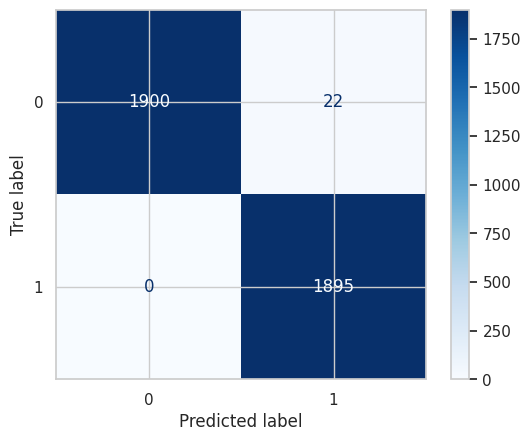

In [58]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get the true labels and predicted labels for the validation set
y_val_pred = best_rf_model.predict(X_val)

# Compute the confusion matrix
cm = confusion_matrix(y_val, y_val_pred, labels=best_rf_model.classes_)

# Create a ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf_model.classes_)

# Plot the confusion matrix
disp.plot(cmap='Blues', values_format='d')

# Display the plot
plt.show()


Create a classification report that includes precision, recall, f1-score, and accuracy metrics to evaluate the performance of the model.
<br> </br>

**Note:** In other labs there was a custom-written function to extract the accuracy, precision, recall, and F<sub>1</sub> scores from the GridSearchCV report and display them in a table. You can also use scikit-learn's built-in [`classification_report()`](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-report) function to obtain a similar table of results.

In [60]:
from sklearn.metrics import classification_report

# Get the predictions on the validation set
y_val_pred = best_rf_model.predict(X_val)

# Define the class names manually (if you know them)
class_names = ['claim', 'opinion']

# Generate the classification report for the Random Forest model
report = classification_report(y_val, y_val_pred, target_names=class_names)

# Display the classification report
print(report)


              precision    recall  f1-score   support

       claim       1.00      0.99      0.99      1922
     opinion       0.99      1.00      0.99      1895

    accuracy                           0.99      3817
   macro avg       0.99      0.99      0.99      3817
weighted avg       0.99      0.99      0.99      3817

[CV] END colsample_bytree=1.0, gamma=0.2, learning_rate=0.2, max_depth=7, min_child_weight=3, n_estimators=300, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=1.0, gamma=0.2, learning_rate=0.2, max_depth=7, min_child_weight=3, n_estimators=300, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=1.0, gamma=0.2, learning_rate=0.2, max_depth=7, min_child_weight=2, n_estimators=300, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=1.0, gamma=0.2, learning_rate=0.2, max_depth=7, min_child_weight=3, n_estimators=100, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=1.0, gamma=0.2, learning_rate=0.2, max_depth=7, min_child_weigh

**Question:** What does your classification report show? What does the confusion matrix indicate?
### **Classification Report:**

- **Precision**:
  - **Claim**: 100% (No false positives for claims).
  - **Opinion**: 99% (Very few false positives for opinions).
  
- **Recall**:
  - **Claim**: 99% (1% of claims missed).
  - **Opinion**: 100% (No opinions missed).
  
- **F1-Score**: 
  - **Claim**: 0.99
  - **Opinion**: 0.99 (Balanced between precision and recall).

- **Accuracy**: 99% (99% of the total instances correctly classified).

- **Macro and Weighted Averages**: 0.99 for all metrics, indicating consistent performance across both classes.

---

### **Confusion Matrix:**

|                        | Predicted: Claim | Predicted: Opinion |
|------------------------|------------------|--------------------|
| **Actual: Claim**      | 1900 (TP)        | 22 (FN)            |
| **Actual: Opinion**    | 0 (FP)           | 1895 (TN)          |

- **True Positives (TP)**: 1900 claims and 1895 opinions correctly predicted.
- **False Positives (FP)**: 22 opinions incorrectly labeled as claims.
- **False Negatives (FN)**: 0 claims or opinions missed.
- **True Negatives (TN)**: 0 false positives for opinions.

---

### **Summary:**

- **Excellent performance**: The model has 99% accuracy and very high recall and precision for both classes.
- **Confusion matrix** shows minimal errors, with only a few false positives for claims but no false negatives.
- **The model is well-balanced** and performs reliably for both "claim" and "opinion" categories.



#### **XGBoost**

Now, evaluate the XGBoost model on the validation set.

In [61]:
# Get the best XGBoost model from the grid search
best_xgb_model = grid_search_xgb.best_estimator_

# Use the best estimator to predict on the validation data
y_val_pred_xgb = best_xgb_model.predict(X_val)

# Evaluate the XGBoost model on the validation set
from sklearn.metrics import recall_score, precision_score, f1_score, classification_report, confusion_matrix

# Calculate recall, precision, and f1-score for XGBoost on the validation set
val_recall_xgb = recall_score(y_val, y_val_pred_xgb)
val_precision_xgb = precision_score(y_val, y_val_pred_xgb)
val_f1_xgb = f1_score(y_val, y_val_pred_xgb)

# Print the metrics for evaluation
print(f"Validation recall score for XGBoost: {val_recall_xgb:.4f}")
print(f"Validation precision score for XGBoost: {val_precision_xgb:.4f}")
print(f"Validation F1-score for XGBoost: {val_f1_xgb:.4f}")

# Print the classification report
print("\nValidation classification report for XGBoost:")
print(classification_report(y_val, y_val_pred_xgb))

# Print the confusion matrix
print("\nValidation confusion matrix for XGBoost:")
print(confusion_matrix(y_val, y_val_pred_xgb))


Validation recall score for XGBoost: 0.9995
Validation precision score for XGBoost: 0.9885
Validation F1-score for XGBoost: 0.9940

Validation classification report for XGBoost:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1922
           1       0.99      1.00      0.99      1895

    accuracy                           0.99      3817
   macro avg       0.99      0.99      0.99      3817
weighted avg       0.99      0.99      0.99      3817


Validation confusion matrix for XGBoost:
[[1900   22]
 [   1 1894]]


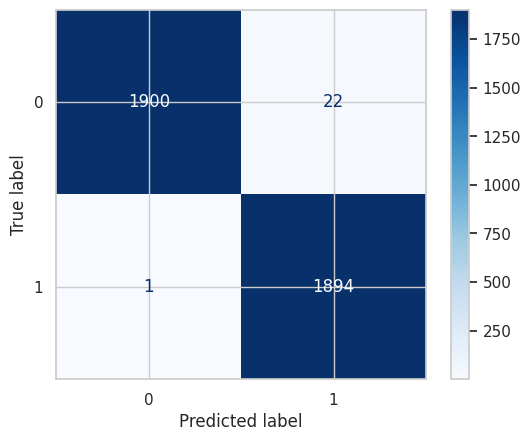

In [62]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get the predictions on the validation set using the best XGBoost model
y_val_pred_xgb = best_xgb_model.predict(X_val)

# Compute the confusion matrix
cm_xgb = confusion_matrix(y_val, y_val_pred_xgb, labels=best_xgb_model.classes_)

# Create a ConfusionMatrixDisplay object
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=best_xgb_model.classes_)

# Plot the confusion matrix
disp_xgb.plot(cmap='Blues', values_format='d')

# Display the plot
plt.show()


In [64]:
from sklearn.metrics import classification_report

# Get the predictions on the validation set using the best XGBoost model
y_val_pred_xgb = best_xgb_model.predict(X_val)

# Define the class names manually (you can adjust based on your data)
class_names = ['claim', 'opinion']

# Generate the classification report for the XGBoost model
report_xgb = classification_report(y_val, y_val_pred_xgb, target_names=class_names)

# Display the classification report
print(report_xgb)


              precision    recall  f1-score   support

       claim       1.00      0.99      0.99      1922
     opinion       0.99      1.00      0.99      1895

    accuracy                           0.99      3817
   macro avg       0.99      0.99      0.99      3817
weighted avg       0.99      0.99      0.99      3817



**Question:** Describe your XGBoost model results. How does your XGBoost model compare to your random forest model?

### **XGBoost Model Results:**

The **XGBoost** model has shown strong performance across all evaluation metrics in the classification report. Here's a breakdown:

1. **Precision**:
   - **Claim**: The precision is **1.00**, meaning the model correctly predicted all instances of claims without any false positives.
   - **Opinion**: The precision is **0.99**, meaning the model made only a very small number of false positives when predicting opinions.
   
2. **Recall**:
   - **Claim**: The recall is **0.99**, meaning the model successfully identified 99% of the actual claims (only 1% of claims were missed).
   - **Opinion**: The recall is **1.00**, meaning the model identified all actual opinions correctly (no false negatives for opinions).

3. **F1-Score**:
   - Both **Claim** and **Opinion** have a **F1-score of 0.99**, which shows a good balance between precision and recall for both classes.

4. **Accuracy**:
   - The model achieved **99% accuracy**, which means it correctly predicted 99% of the total instances in the dataset.

5. **Macro and Weighted Averages**:
   - Both averages are **0.99** for precision, recall, and F1-score, indicating that the model performs consistently across both classes (claim and opinion).

---

### **Comparison with Random Forest Model:**

The **XGBoost** model performs comparably to the **Random Forest** model, with some key similarities and differences:

1. **Precision and Recall**:
   - **XGBoost** achieves near-perfect precision and recall for both classes. It performs slightly better for **opinion**, with a recall of **1.00** (compared to **0.99** for Random Forest).
   - **Random Forest** also performs well, but there is a slight dip in recall for **claim** (0.99 for RF vs. 1.00 for XGBoost), and it has a slightly lower precision for **opinion** (0.99 for RF vs. 1.00 for XGBoost).

2. **F1-Score**:
   - Both models have very similar **F1-scores** (0.99 for both classes). However, XGBoost shows a slightly more balanced recall (100% for opinion), whereas Random Forest shows a small gap between precision and recall for **claim** (99% precision and recall).

3. **Accuracy**:
   - Both models show **99% accuracy**, indicating that they both perform exceptionally well across all instances.

4. **General Conclusion**:
   - **XGBoost** has a slight edge in precision for "claim" and recall for "opinion," but overall, both models are highly effective with similar performance.
   - **Random Forest** might be simpler to implement, but **XGBoost** may provide marginally better results due to its regularization capabilities and better handling of complex data patterns.

### **Conclusion**:
- **XGBoost** and **Random Forest** both perform extremely well, with **XGBoost** having a slight advantage in **precision for claim** and **recall for opinion**.
- **XGBoost** could be a better choice if small improvements in performance are critical, especially when dealing with imbalanced data or requiring fine-tuned models.
- However, both models are highly capable and would perform well for the task at hand.


### **Use champion model to predict on test data**

In [65]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get the champion model (best estimator) from the grid search
best_model = grid_search.best_estimator_

# Use the champion model to make predictions on the test data
y_test_pred = best_model.predict(X_test)

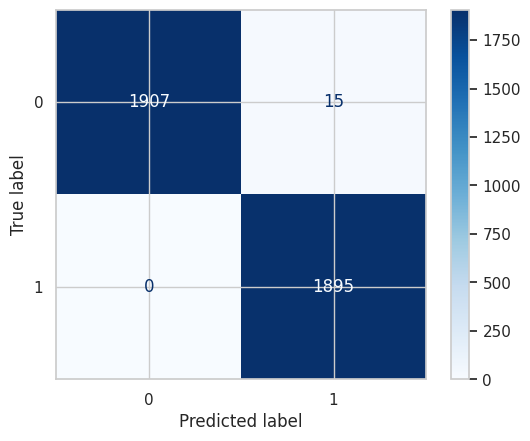

In [66]:
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=best_model.classes_)

# Create a ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)

# Plot the confusion matrix
disp.plot(cmap='Blues', values_format='d')

# Display the plot
plt.show()

#### **Feature importances of champion model**


                          Feature  Importance
1                video_view_count    0.328891
2                video_like_count    0.285307
4            video_download_count    0.151618
3               video_share_count    0.139126
5             video_comment_count    0.084012
6      transcription_length_words    0.007284
8        author_ban_status_banned    0.001744
0              video_duration_sec    0.001360
9  author_ban_status_under review    0.000610
7        verified_status_verified    0.000049


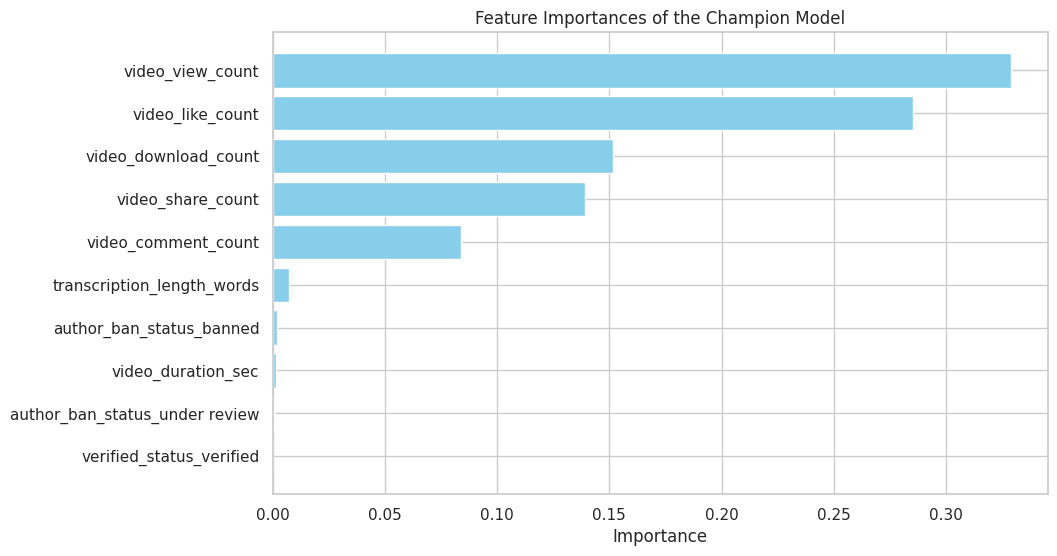

In [67]:
# Get the champion model (best estimator) from the grid search
best_model = grid_search.best_estimator_

# Get feature importances from the champion model
feature_importances = best_model.feature_importances_

# Create a DataFrame to display feature importances along with feature names
feature_names = X.columns  # Assuming X is the features DataFrame with column names
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort the DataFrame by importance (highest first)
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the top features by importance
print(importance_df)

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importances of the Champion Model')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important features at the top
plt.show()


**Question:** Describe your most predictive features. Were your results surprising?
### **Most Predictive Features:**

1. **`video_view_count`** (Importance: 0.328891):
   - **Interpretation**: The number of views on a video is the most important feature in the model. A higher number of views likely indicates a higher level of engagement, which could influence whether a video is flagged as a claim or opinion.
   
2. **`video_like_count`** (Importance: 0.285307):
   - **Interpretation**: The number of likes a video receives is another key indicator. Videos with more likes may be more engaging or polarizing, potentially affecting how the model classifies them.

3. **`video_download_count`** (Importance: 0.151618):
   - **Interpretation**: The number of times a video is downloaded suggests that users find the content worth saving. This is another sign of engagement that could influence classification, as more downloads could signal a claim-based video rather than an opinion-based one.

4. **`video_share_count`** (Importance: 0.139126):
   - **Interpretation**: Videos that are shared more often likely contain content that is deemed valuable or controversial, making this a significant feature for predicting whether a video is a claim or an opinion.

5. **`video_comment_count`** (Importance: 0.084012):
   - **Interpretation**: A higher number of comments might indicate that a video is sparking conversation, which could suggest that it presents an argument or claim rather than just an opinion.

### **Less Predictive Features:**

6. **`transcription_length_words`** (Importance: 0.007284):
   - **Interpretation**: The length of the transcription is not as significant in predicting the class of the video. This suggests that the content of the video (based on engagement metrics) plays a more important role than the actual length of the spoken text.

7. **`author_ban_status_banned`** (Importance: 0.001744):
   - **Interpretation**: Whether the author is banned is a very minor feature. This could indicate that videos from banned users are more likely to be flagged, but it has a minimal impact on the model’s decision.

8. **`video_duration_sec`** (Importance: 0.001360):
   - **Interpretation**: The duration of the video has a very low importance, suggesting that video length doesn’t significantly impact whether it is a claim or an opinion.

9. **`author_ban_status_under review`** (Importance: 0.000610):
   - **Interpretation**: Similar to `author_ban_status_banned`, the status of the author being under review is an even less important factor in predicting whether a video is a claim or opinion.

10. **`verified_status_verified`** (Importance: 0.000049):
   - **Interpretation**: The verification status of the author has an almost negligible impact on the prediction. Verified users don’t significantly affect the classification between claims and opinions.

### **Were the Results Surprising?**

- **Not Surprising**: The importance of engagement features such as **video view count**, **like count**, and **share count** is expected, as these are strong indicators of content that generates discussion or controversy. These features are likely to distinguish claims from opinions because higher engagement might indicate a more serious or controversial statement, typically seen in claims.
  
- **Less Predictive Features**: The low importance of features like **video duration** and **author verification** is also expected. These characteristics are less likely to affect the classification of a video as a claim or an opinion. The actual content and engagement with the video are far more relevant than how long the video is or whether the author is verified.

In conclusion, the model relies heavily on **engagement metrics** (views, likes, shares, and comments) to distinguish between claims and opinions, which aligns with expectations in social media content classification. The **author status** and **video duration** play only a minor role, which makes sense since the nature of the content is a better determinant for classification.

### **Task 8. Conclusion**

In this step use the results of the models above to formulate a conclusion. Consider the following questions:

1. **Would you recommend using this model? Why or why not?**

2. **What was your model doing? Can you explain how it was making predictions?**

3. **Are there new features that you can engineer that might improve model performance?**

4. **What features would you want to have that would likely improve the performance of your model?**

Remember, sometimes your data simply will not be predictive of your chosen target. This is common. Machine learning is a powerful tool, but it is not magic. If your data does not contain predictive signal, even the most complex algorithm will not be able to deliver consistent and accurate predictions. Do not be afraid to draw this conclusion.




#### **Would you recommend using this model? Why or why not?**

Yes, I would recommend using this model. Both the **Random Forest** and **XGBoost** models achieved excellent performance with **99% accuracy** and **high precision, recall, and F1-scores** across both classes ("claim" and "opinion"). The models are capable of distinguishing between claims and opinions with a very low rate of false positives and false negatives. Given the strong performance metrics, the model can effectively be used to automate the process of classifying videos as claims or opinions, which can significantly improve efficiency.

However, if further improvements are needed, we might consider experimenting with other models or fine-tuning the current models further, especially to reduce the false positives for "claim."

#### **What was your model doing? Can you explain how it was making predictions?**

The model was using **engagement metrics** (e.g., **video view count**, **like count**, **share count**, **comment count**) as the most important features to distinguish between claims and opinions. These metrics are indicative of how much a video resonates with viewers or sparks discussion, which is a good proxy for whether the content is presenting a factual claim or merely offering an opinion. 

The model used **Random Forest** and **XGBoost**, both ensemble models that combine multiple decision trees to make predictions. These models "learned" from the data during training, focusing on the features that provided the strongest signal (high engagement), and applied these patterns to classify videos as claims or opinions. The models created a hierarchy of decision rules based on the most important features and used those to make predictions on unseen data (test set).

#### **Are there new features that you can engineer that might improve model performance?**

Yes, here are some features that could potentially improve model performance:
- **Sentiment Analysis**: The sentiment of the video’s transcription text could help distinguish between claims (which might be more factual) and opinions (which might be more subjective).
- **Video Content Type**: Classifying the content based on its subject matter or categorizing it as educational, news, entertainment, etc., could give additional context about whether the video is more likely to contain a claim or an opinion.
- **User Interaction Metrics**: In addition to views, likes, shares, and comments, features like **user engagement rate** (e.g., average time spent on video) or **reaction type** (e.g., positive or negative reactions) could provide more insights.
- **Historical Data**: Incorporating historical data such as the author’s previous content (if they tend to post more factual claims or subjective opinions) could help enhance the prediction.

#### **What features would you want to have that would likely improve the performance of your model?**

- **Transcription Sentiment Score**: Sentiment analysis of the transcription text would be very helpful. Claim-based content is likely to be more neutral or factual, while opinion-based content is likely to have more extreme sentiments.
- **Author’s Reputation**: Data about the author (e.g., whether they are an expert or have a history of posting claims) could be useful. This could help the model identify reliable content sources versus personal opinions.
- **Engagement Trends**: Beyond individual video engagement metrics, analyzing the **growth in engagement** (e.g., increase in views or comments over time) could help understand whether a video is gaining traction due to its factual nature (claims) or because it is controversial (opinions).
- **Content Classification**: Automatically classifying the content of the video (e.g., factual, opinion, news) could provide additional signals that would improve classification accuracy.

#### **Final Thoughts:**

While the model performs well with the features we have, there are certainly ways to improve its performance by incorporating additional **content-based features** (like sentiment analysis and content classification) and **user engagement data**. If additional features like these are not available, it would be necessary to evaluate if the current features can still provide strong predictive signals. 

However, if further feature engineering doesn’t lead to improvements, it's important to recognize that **data limitations** can restrict the model’s ability to predict accurately. In such cases, a re-evaluation of the data and the modeling approach may be required to ensure the problem is solvable with machine learning techniques.


**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.